## **Optimización y evaluación del modelo XGBoost**

En este capítulo se presenta el desarrollo, ajuste y evaluación detallada del modelo XGBoost. Si bien otros enfoques como la regresión lineal con transformación logarítmica y las redes neuronales mostraron un rendimiento competitivo, el presente apartado se enfoca exclusivamente en XGBoost debido a su capacidad para capturar relaciones no lineales, manejar variables categóricas codificadas y ofrecer un equilibrio adecuado entre precisión y generalización. La comparación global entre modelos se aborda posteriormente en el apartado de conclusiones.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset/car_sales_data_clean.csv')

In [ ]:
df.head()

,Fabricante,Modelo,Motor,Combustible,Año,Kilometraje,Precio
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,VW,Polo,1.0,Petrol,2006,127869,4101
4,Ford,Focus,1.4,Petrol,2018,33603,29204


In [ ]:
X = df.drop(['Precio'], axis=1)
y = df['Precio']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train,X_val,y_train,y_val = train_test_split(X_train,y_train,test_size=0.25,random_state=42)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import  OneHotEncoder

In [ ]:
cat_features = ['Fabricante','Modelo','Combustible']


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)


In [ ]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
def evaluar_estimadores(max_estimators, lr, max_depth_):
    resultados = []

    for n in max_estimators:
        xgb = XGBRegressor(
            n_estimators=n,
            max_depth=max_depth_,
            learning_rate=lr,
            random_state=42,
            device="cuda",
            n_jobs=-1
        )

        xgb_pipeline = Pipeline(steps=[
            ('preprocess', preprocessor),
            ('model', xgb)
        ])

        # Entrenar el modelo
        xgb_pipeline.fit(X_train, y_train)

        # Predicciones
        y_train_pred = xgb_pipeline.predict(X_train)
        mae_train = mean_absolute_error(y_train, y_train_pred)

        y_test_pred = xgb_pipeline.predict(X_test)
        mae_test = mean_absolute_error(y_test, y_test_pred)

        y_val_pred = xgb_pipeline.predict(X_val)
        mae_val = mean_absolute_error(y_val, y_val_pred)

        # Guardar resultados
        resultados.append({
            'n_estimators': n,
            'MAE Train': mae_train,
            'MAE Test': mae_test,
            'MAE Val': mae_val
        })

    # Convertir a DataFrame
    df_resultados = pd.DataFrame(resultados)
    return df_resultados


## **Experimento 1 – XGBoost Regressor con parámetros conservadores**

In [ ]:
n_estimators = np.arange(100,1000,10)
max_depth = 5
learning_rate = 0.01

In [ ]:
prueba1 = evaluar_estimadores(n_estimators,learning_rate,max_depth)

In [ ]:
prueba1[prueba1['n_estimators']>=900]

,n_estimators,MAE Train,MAE Test,MAE Val
80,900,471.198090,503.164093,501.726074
81,910,467.147949,499.208191,497.729156
82,920,462.575989,494.714386,493.284332
83,930,458.323456,490.528900,489.209503
84,940,455.092865,487.310791,486.087311
85,950,451.491669,483.749451,482.590027
86,960,447.730865,480.039948,478.950073
87,970,444.445099,476.776581,475.741699
88,980,441.105499,473.437561,472.480927
89,990,437.821991,470.102295,469.383850


* En este primer experimento se evaluó el desempeño de un modelo XGBoost Regressor utilizando un rango de n_estimators de 100 a 990 con incrementos de 10, una **profundidad de árbol** (max_depth) de 5 y una tasa de aprendizaje (learning_rate) de 0.01. Los resultados mostraron un MAE de entrenamiento de **437**, **470** y **469** USD, lo cual representa una mejora significativa respecto a la regresión lineal múltiple, cuyo MAE superaba los 600 USD.

* En esta iteración se decidió mantener parámetros conservadores tanto para la profundidad del árbol como para la tasa de aprendizaje. Esta estrategia permitió que el modelo **generalizara** correctamente sin presentar síntomas de sobreajuste, ya que los errores de entrenamiento y validación se mantuvieron estables a lo largo de las iteraciones.

* El experimento demuestra que XGBoost es capaz de capturar **relaciones no lineales** en los datos, superando así el desempeño de modelos lineales tradicionales. Mantener una configuración conservadora en los hiperparámetros fue clave para evitar el sobreajuste y lograr un modelo robusto y estable, que logra un equilibrio adecuado entre precisión y capacidad de generalización.

## **Experimento 2 – Aumento de profundidad y learning rate muy conservador**

In [ ]:
n_estimators = np.arange(100,1000,10)
max_depth = 6
learning_rate = 0.001

In [ ]:
prueba2 = evaluar_estimadores(n_estimators,learning_rate,max_depth)

In [ ]:
prueba2[prueba2['n_estimators']>=900]

,n_estimators,MAE Train,MAE Test,MAE Val
80,900,5107.811035,5035.703613,5127.660156
81,910,5062.782227,4991.569824,5082.527344
82,920,5018.185547,4947.841309,5037.819824
83,930,4974.202148,4904.816406,4993.802734
84,940,4930.579590,4862.071289,4950.060547
85,950,4887.608398,4819.994141,4907.029297
86,960,4845.014648,4778.301758,4864.374512
87,970,4802.750977,4736.837891,4822.016602
88,980,4760.949707,4695.975586,4780.142578
89,990,4719.511719,4655.412598,4738.625000


* En el segundo experimento se mantuvo el rango de n_estimators con incrementos de 10, pero se decidió ser más conservador con la **tasa de aprendizaje**, utilizando un valor de **0.001**, y al mismo tiempo se aumentó la **profundidad máxima del árbol** a **7**. La intención era que, al permitir que el árbol aprendiera patrones más complejos de manera muy gradual, el modelo pudiera mejorar el MAE respecto al experimento anterior.

* Sin embargo, los **resultados fueron contrarios** a lo esperado, mostrando un MAE superior a 4,500 USD. Esto indica que, aunque la tasa de aprendizaje era extremadamente baja, la mayor profundidad del árbol provocó un sobreajuste extremo al conjunto de entrenamiento, impidiendo que el modelo generalizara correctamente a los datos de validación y prueba.

* Este experimento evidencia la importancia de balancear la profundidad del árbol con la tasa de aprendizaje, ya que un aumento excesivo en la complejidad puede afectar negativamente el rendimiento. A pesar de la intención de ser muy conservador con el learning rate, la combinación con una profundidad de 7 resultó contraproducente, mostrando que la profundidad del árbol es un hiperparámetro crítico que debe ajustarse cuidadosamente para lograr un modelo robusto y estable.

## **Experimento 3 – Profundidad mayor y learning rate conservador**

In [ ]:
n_estimators = np.arange(100,1000,10)
max_depth = 7
learning_rate = 0.01

In [ ]:
prueba3 = evaluar_estimadores(n_estimators,learning_rate,max_depth)

In [ ]:
prueba3[prueba3['n_estimators']>=900]

,n_estimators,MAE Train,MAE Test,MAE Val
80,900,238.035583,294.397125,290.776733
81,910,236.543350,292.862152,289.245361
82,920,235.316483,291.595795,287.932648
83,930,233.959946,290.176941,286.527496
84,940,232.559448,288.722687,285.094635
85,950,231.018387,287.200439,283.678284
86,960,229.896973,286.020660,282.505402
87,970,228.709122,284.764252,281.287262
88,980,227.357269,283.355164,279.960968
89,990,226.317505,282.243744,278.905396


* En el tercer experimento se **aumentó la profundidad máxima** del árbol a 7 y se mantuvo una **tasa de aprendizaje conservadora** de 0.01. Dada la mayor profundidad del árbol, se esperaba un sobreajuste pronunciado, ya que un modelo muy profundo puede ajustarse demasiado a los datos de entrenamiento.

* Sin embargo, los resultados fueron sorprendentes: se obtuvo un MAE de entrenamiento de **226 USD**, un MAE de prueba de **282 USD** y un MAE de validación de **278 USD.** Esto indica que, a pesar de la profundidad elevada, el modelo logró generalizar correctamente gracias a la tasa de aprendizaje baja, evitando el sobreajuste y manteniendo un buen equilibrio entre precisión y capacidad de generalización.

* Este experimento demuestra que la combinación de profundidad mayor con un learning rate conservador permite capturar relaciones complejas en los datos sin comprometer la estabilidad del modelo. La mejora significativa en el MAE en comparación con los experimentos anteriores resalta la importancia de ajustar cuidadosamente los hiperparámetros y de no asumir que un aumento en profundidad siempre causará sobreajuste.

## **Experimento 4 – Profundidad moderada y learning rate alto**

In [ ]:
n_estimators = np.arange(100,1000,10)
max_depth = 5
learning_rate = 0.1

In [ ]:
prueba4 = evaluar_estimadores(n_estimators,learning_rate,max_depth)

In [ ]:
prueba4[prueba4['n_estimators']>=900]

,n_estimators,MAE Train,MAE Test,MAE Val
80,900,134.449219,177.630753,176.672348
81,910,133.331070,176.624115,175.559326
82,920,132.345917,175.786514,174.773209
83,930,131.244781,174.858719,173.813644
84,940,129.749542,173.445557,172.405869
85,950,128.807861,172.622406,171.586548
86,960,127.752419,171.723679,170.585236
87,970,126.753151,170.739929,169.656296
88,980,126.038841,170.081223,169.088715
89,990,125.159813,169.358398,168.413574


* En el cuarto experimento se ajustaron los hiperparámetros para ser menos agresivo con la **profundidad del árbol**, reduciéndola a un máximo de 5, mientras que se incrementó la tasa de aprendizaje a 0.1. Esta decisión buscaba controlar el riesgo de sobreajuste que podría generar un learning rate elevado manteniendo la complejidad del modelo moderada.

* Los resultados fueron muy positivos: se obtuvo un MAE de entrenamiento de **125 USD**, un MAE de prueba de **169 USD** y un MAE de validación de **168 USD**. Esto demuestra que, al combinar una profundidad más conservadora con un learning rate alto, el modelo logró aprender de manera más eficiente, reduciendo significativamente los errores en comparación con los experimentos anteriores y manteniendo una buena capacidad de generalización.

## **Experimento 5 – Incremento moderado de profundidad con learning rate alto**

In [ ]:
n_estimators = np.arange(100,1000,10)
max_depth = 6
learning_rate = 0.1

In [ ]:
prueba5 = evaluar_estimadores(n_estimators,learning_rate,max_depth)

In [ ]:
prueba5[prueba5['n_estimators']>=900]

,n_estimators,MAE Train,MAE Test,MAE Val
80,900,96.163498,161.325150,158.617798
81,910,95.273720,160.659668,157.917465
82,920,94.536903,160.072388,157.391586
83,930,93.998024,159.741714,157.071304
84,940,93.187225,159.138489,156.484589
85,950,92.457085,158.478439,155.875229
86,960,91.696266,157.873627,155.260132
87,970,91.002197,157.318161,154.699341
88,980,90.324341,156.799393,154.158142
89,990,89.542191,156.185394,153.557907


* En el quinto experimento se decidió mantener una **tasa de aprendizaje** de 0.1 y aumentar ligeramente la **profundidad máxima** del árbol a 6, con el objetivo de observar cómo impactaba un pequeño incremento en la complejidad del modelo. Esta prueba surgió por interés experimental, buscando identificar si un ajuste intermedio entre profundidad moderada y alta podía ofrecer mejores resultados sin inducir sobreajuste.

* Los resultados fueron **notablemente positivos**, obteniendo un MAE de entrenamiento de 90 USD, un MAE de prueba de 156 USD y un MAE de validación de 153 USD. Estos valores representan una mejora considerable respecto a experimentos anteriores y muestran una alta capacidad predictiva del modelo.

* No obstante, se puede observar que el error en entrenamiento es significativamente menor que en prueba y validación, lo que sugiere que el modelo se ajusta con mayor precisión a los datos de entrenamiento. Aunque la diferencia no es extrema y los valores de prueba y validación se mantienen cercanos entre sí —lo cual indica estabilidad—, sí puede interpretarse como un ligero indicio de tendencia al sobreajuste.

In [ ]:
xgb = XGBRegressor(
    random_state=42,
    device="cuda",
    n_estimators = 990,
    learning_rate = 0.1,
    max_depth = 5,
    n_jobs=-1
)


In [ ]:
pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', xgb)
])


### **Búsqueda de hiperparámetros mediante Grid Search**

In [ ]:
param_grid = {

    'model__min_child_weight': [1,3,5,7],
    'model__subsample': [0.8,0.9,1],
    'model__reg_lambda': [1,3,5,7]
}


* El hiperparámetro **min_child_weight** controla el peso mínimo de las observaciones necesarias para que el algoritmo genere una nueva rama en un árbol de decisión. Valores más altos hacen al modelo más conservador, evitando divisiones basadas en pocos datos y reduciendo el riesgo de sobreajuste.

* El parámetro **subsample** define la proporción de datos utilizada para entrenar cada árbol. Al emplear valores menores a 1, el modelo introduce aleatoriedad en el entrenamiento, lo que contribuye a disminuir la varianza y mejora la capacidad de generalización del algoritmo.

* Por último, **reg_lambda** corresponde al término de regularización L2 del modelo, equivalente conceptualmente a la regresión Ridge. Este parámetro penaliza los valores elevados de los pesos, ayudando a controlar la complejidad del modelo y a prevenir el sobreajuste, especialmente en escenarios con múltiples variables predictoras.

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=2,
    n_jobs=-1,
)


In [ ]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Fabricante',
                                                                          'Modelo',
                                                                          'Combustible'])])),
                                       ('model',
                                        XGBRegressor(base_score=None,
                                                     booster=None,
                                                     callbacks=None,
                                                     colsample_bylevel=None,
                                                     colsample_bynode=None,
                                                     colsample_bytree=None,
                                                     device='cuda',
                                                     e...
                                                     max_delta_step=None,
                                                     max_depth=5,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=990,
                                                     n_jobs=-1,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__min_child_weight': [1, 3, 5, 7],
                         'model__reg_lambda': [1, 3, 5, 7],
                         'model__subsample': [0.8, 0.9, 1]},
             scoring='neg_mean_absolute_error', verbose=2)

In [ ]:
grid.best_params_

{'model__max_depth': 6,
 'model__min_child_weight': 1,
 'model__reg_lambda': 1,
 'model__subsample': 0.8}

In [ ]:
xgb = XGBRegressor(
    random_state=42,
    n_estimators = 990,
    learning_rate = 0.1,
    max_depth = 5,
    subsample = 0.8,
    n_jobs=-1
)

In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', xgb)
])

In [ ]:
xgb_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Fabricante', 'Modelo',
                                                   'Combustible'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enab...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=990, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [ ]:
importancias = xgb.feature_importances_
feature_names = xgb_pipeline.named_steps['preprocess'].get_feature_names_out()


In [ ]:
df_importancias = pd.DataFrame({
    'feature': feature_names,
    'importance': importancias
}).sort_values(by='importance', ascending=False)

## **Optimización y evaluación del modelo XGBoost**

| Modelo                              | MAE Train | MAE Test   | MAE Validación |
| ----------------------------------- | --------- | ---------- | -------------- |
| Regresión Lineal Múltiple (sin log) | 5,873     | 5,784      | 6,033          |
| Regresión Lineal Múltiple (con log) | 663       | 644        | 674            |
| Random Forest                       | 2,685     | 2,676      | 2,702          |
| Gradient Boosting                   | 1,092     | 1,105      | 1,129          |
| XGBoost (base)                      | 958       | 973        | 991            |
| **XGBoost (optimizado)**            | **127.53**    | **173.36** | **171.81**        |
| Red Neuronal (TensorFlow)           | 190       | 184        | 195            |



* En una primera etapa del análisis, se entrenó un modelo XGBoost utilizando una configuración base, con el objetivo de establecer una comparación inicial frente a otros enfoques como la regresión lineal múltiple, Random Forest, Gradient Boosting y una red neuronal implementada en TensorFlow. En esta comparación preliminar, el modelo XGBoost presentó un desempeño competitivo, aunque inferior al de la red neuronal y a la regresión lineal con transformación logarítmica.

* Posteriormente, se llevó a cabo una fase de experimentación y ajuste de hiperparámetros del modelo XGBoost, explorando distintas combinaciones de número de estimadores, profundidad máxima de los árboles y tasa de aprendizaje. Como resultado de este proceso de optimización, el desempeño del modelo mejoró de manera significativa, reduciendo el error MAE en los conjuntos de entrenamiento, validación y prueba hasta valores cercanos a los **130–170 dólares**.

* Estos resultados evidencian el impacto del ajuste de hiperparámetros en modelos basados en árboles de decisión y demuestran que, bajo una configuración adecuada, XGBoost puede superar tanto a modelos lineales como a enfoques más complejos como las redes neuronales, especialmente en problemas de datos tabulares como la predicción de precios de vehículos usados.

### **Conclusión sobre la importancia de variables**

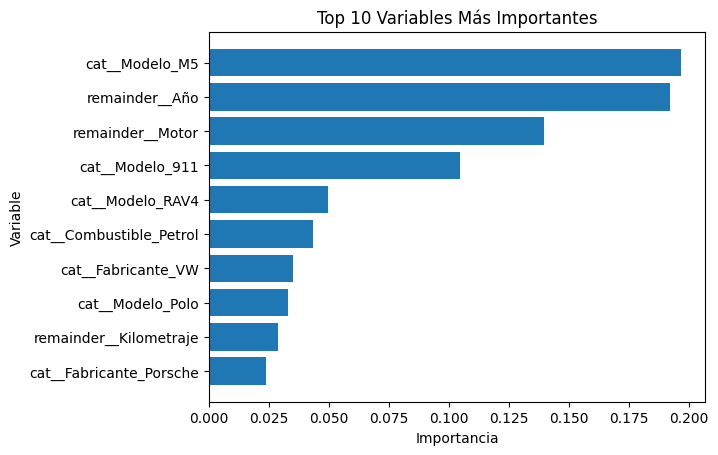

In [ ]:
plt.figure()
plt.barh(df_importancias['feature'][:10],
         df_importancias['importance'][:10])
plt.title('Top 10 Variables Más Importantes')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.gca().invert_yaxis()
plt.show()



* Al analizar las diez variables más influyentes del modelo, se observó que algunas variables *dummy* correspondientes al nombre del **modelo** del vehículo presentan una importancia elevada, lo cual resulta coherente debido a que el modelo del automóvil influye de forma significativa en su precio de mercado. Asimismo, variables numéricas como el **año** del vehículo se posicionan entre las más relevantes, ya que reflejan directamente la depreciación natural del automóvil con el paso del tiempo. De manera destacada, la variable **motor** aparece como la tercera más importante dentro del ranking, lo que indica que las características del motor influyen de forma directa en la valuación del vehículo, ya sea por desempeño, consumo, confiabilidad o segmento de mercado.

* Por otro lado, la variable **kilometraje**, aunque se ubica en el noveno lugar dentro del ranking, continúa siendo un factor importante en la predicción del precio. Su posición puede explicarse porque otras variables, como el modelo, el año y el tipo de motor, ya capturan parcialmente el efecto del desgaste del vehículo. Esto no implica que el kilometraje carezca de influencia, sino que su aporte se complementa con otras características que describen el estado general y el valor comercial del automóvil. En conjunto, estos resultados indican que el modelo está identificando patrones alineados con la lógica real del mercado automotriz.


In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
def MAE(y_true,X_data):

  y_pred = xgb_pipeline.predict(X_data)
  mae = mean_absolute_error(y_true,y_pred)

  return round(mae,2)

In [ ]:
print(f"MAE Test: {MAE(y_train,X_train)}")
print(f"MAE Test: {MAE(y_test,X_test)}")
print(f"MAE Test: {MAE(y_val,X_val)}")

MAE Test: 127.53
MAE Test: 173.36
MAE Test: 171.81


In [ ]:
def prediciones(fabricante,modelo,motor,combustible,año,Kilometraje):
  x = pd.DataFrame({
      'Fabricante':[fabricante],
      'Modelo':[modelo],
      'Motor':[motor],
      'Combustible':[combustible],
      'Año':[año],
      'Kilometraje':[Kilometraje]
  })

  y_pred = xgb_pipeline.predict(x)
  return y_pred

In [ ]:
prediciones("VW","Jetta",2.0,"Petrol",2014,130067)

array([13637.811], dtype=float32)

In [ ]:
prediciones("BMW","M3",3.0,"Petrol",2023,4500)

array([81105.05], dtype=float32)

### **Conclusión**

* Si bien la **regresión lineal múltiple** presentó limitaciones en su forma original, la aplicación de una **transformación logarítmica** sobre la variable objetivo permitió mejorar de manera significativa su desempeño. Bajo este enfoque, la regresión lineal logró resultados competitivos, colocándose a la par de algoritmos más complejos como las redes neuronales y XGBoost, lo que demuestra que un adecuado tratamiento de los datos puede potenciar considerablemente modelos estadísticos tradicionales.

* No obstante, el modelo **XGBoost**, tras un proceso de optimización de hiperparámetros, obtuvo los mejores resultados en términos de error MAE, evidenciando una mayor capacidad para capturar relaciones no lineales y patrones complejos presentes en los datos. Adicionalmente, XGBoost ofrece una ventaja relevante en cuanto a **interpretabilidad** a comparación de las redes neuronales, ya que permite analizar la importancia de las variables de entrada, a diferencia de las redes neuronales, cuyo comportamiento suele ser menos transparente.

* Por otro lado, a diferencia de las redes neuronales, **XGBoost no requiere un preprocesamiento estricto de los datos**, como la estandarización mediante **`StandardScaler`**, debido a que se basa en particiones del espacio de características a través de desigualdades matemáticas propias de los árboles de decisión. En conjunto, estos factores convierten a XGBoost en una alternativa robusta, eficiente e interpretable para la predicción de precios de vehículos usados, especialmente en escenarios de datos tabulares.
